# Grafico de BR
El objetivo es crear un objeto programatico que facilmente permita entregar un grafico de branching ratios para identificar en base a algun parametro como una masa o $\lambda$'s

inputs:
- arreglos correspondientes a distintos BR en forma de diccionario
- dentro del diccionario un arreglo correspondiente al parametro que varia

capacidades a incluir:
- escala logaritmica o lineal
- incluir una cantidad de BR entre 1 a 5


In [ ]:
from lib.oracle import run_oracle, safe_run_oracle
from lib.explorer import explore_points, explore_points_parallel
from lib.utils import estimate_exploration_time, expand_parameter_space
import numpy as np
import matplotlib.pyplot as plt

# parametros globales a utilizar
lambda6 = 0.1
lambda7 = 0.0
# alpha = 1e-7
# beta  = 1.570796226794897
sin_ba_default = 1
tan_beta_default = 1e7

# wrapper para valores fijos
def physpoint(mphi : np.float64, m12_2 : np.float64, mA : np.float64 = 300.0, 
              sin_ba : np.float64  = sin_ba_default, tan_beta : np.float64 = tan_beta_default):
    # Parámetros fijos

    # m_phi, mA, sin_ba, tan_beta, lambda6, lambda7, m12^2
    return safe_run_oracle([mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m12_2])

def simulate_curve(mphi_values, mA, m12, lambda6_val, lambda7_val, sin_ba, tan_beta):
    results = []

    for mphi in mphi_values:
        out = physpoint(mphi, m12, mA, sin_ba, tan_beta)
        if out is not None:
            results.append({
                'mphi': mphi,
                'br': {
                    'gaga': out.get('branching_ratio_h2_gaga', np.nan),
                    'Zga': out.get('w_h2_Zga', 0) / out.get('w_total_h2', 1),
                    'bb':  out.get('w_h2_bb', 0) / out.get('w_total_h2', 1),
                },
                'total_width': out.get('w_total_h2', np.nan),
                'flags': {
                    'positivity': out.get('positivity_ok', 0),
                    'unitarity': out.get('unitarity_ok', 0),
                    'perturbativity': out.get('perturbativity_ok', 0),
                },
                'params': {
                    'mA': mA,
                    'm12': m12,
                    'lambda6': lambda6_val,
                    'lambda7': lambda7_val,
                    'sin_ba': sin_ba,
                    'tan_beta': tan_beta
                }
            })
    return results

# modificar para incorporar los parametros epsilos
def make_title(params, subplot_tag="(d)"):
    mA = params['mA']
    m12 = params['m12']
    lambda6 = params['lambda6']
    lambda7 = params['lambda7']
    tanbeta = params['tan_beta']
    sinba = params['sin_ba']
    return ( #\epsilon_V
        rf"$\sin(\beta-\alpha) = " + f"{sin_ba :.2e}" + " \quad \epsilon_A = 1/ " + f"{tanbeta:.2e} "+  "\quad "
        rf"\Delta\lambda' = {lambda6}\quad "
        rf"m_\phi < m_{{H^\pm}} = m_A = {mA:.0f}$"
        f"\n{subplot_tag}"
    )

def plot_branchings(results, subplot_tag="(d)"):
    import matplotlib.pyplot as plt

    mphi = [r['mphi'] for r in results]
    brs   = {
        'gaga': [r['br']['gaga'] for r in results],
        'Zga':  [r['br']['Zga']  for r in results],
        'bb':   [r['br']['bb']   for r in results],
    }

    fig, ax = plt.subplots(figsize=(5,5))
    # === Agregar puntos sobre la curva donde se cumplen las 3 condiciones físicas ===
    for key, color in zip(['gaga', 'Zga', 'bb'], ['r', 'purple', 'b']):
        valid_x = []
        valid_y = []
        for r in results:
            if all(r['flags'][k] == 1 for k in ['positivity', 'unitarity', 'perturbativity']):
                valid_x.append(r['mphi'])
                valid_y.append(r['br'][key])
        ax.scatter(valid_x, valid_y, color=color, marker='o', edgecolors='k', zorder=5, s=30) #, label=f'✓ {key}')


    ax.plot(mphi, brs['gaga'], 'r--', label=r'$\phi \to \gamma\gamma$')
    ax.plot(mphi, brs['Zga'],  'purple', label=r'$\phi \to Z\gamma$')
    ax.plot(mphi, brs['bb'],   'b:', label=r'$\phi \to b\bar{b}$')

    ax.set_ylim(0, 1)
    ax.set_xlim(min(mphi), max(mphi))
    ax.set_xlabel(r'$m_\phi$ [GeV]')
    ax.set_ylabel('Branching Ratio')
    ax.legend(loc='upper right')

    # # Subgráfico para el total width
    total_widths = [r['total_width'] for r in results]
    inset_ax = ax.inset_axes([0.15, 0.7, 0.35, 0.25])
    inset_ax.plot(mphi, total_widths, 'k:', linewidth=1)
    inset_ax.set_yscale('log')

    # Elegir ticks adecuados
    x_ticks = np.linspace(min(mphi), max(mphi), 4)
    y_ticks = np.logspace(np.floor(np.log10(min(total_widths))),
                          np.ceil(np.log10(max(total_widths))), 3)

    inset_ax.set_xticks(x_ticks)
    inset_ax.set_xticklabels([f"{x:.0f}" for x in x_ticks], fontsize=7)

    inset_ax.set_yticks(y_ticks)
    inset_ax.set_yticklabels([f"{y:.1e}" for y in y_ticks], fontsize=7)

    inset_ax.set_title(r'$\Gamma$ [GeV]', fontsize=8)

    title = make_title(results[0]['params'], subplot_tag)
    ax.set_title(title, fontsize=11)

    plt.tight_layout()
    plt.show()


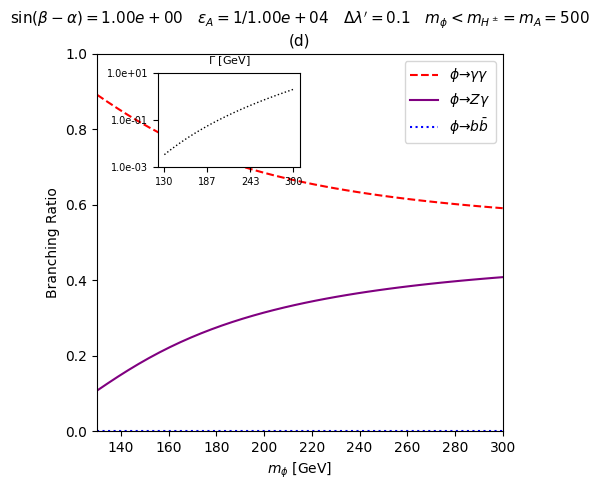

In [28]:
fixed_config = {
    'mA': 500,
    'm12': 0.03,
    'lambda6': 0.1,
    'lambda7': 0.0,
    'sin_ba': 1,
    'tan_beta': 1e4
}

lambda6 = fixed_config['lambda6']
lambda7 = fixed_config['lambda7']
mphi_vals = np.linspace(130, 300, 40)
results = simulate_curve(mphi_vals, fixed_config['mA'], fixed_config['m12'], lambda6, lambda7, fixed_config['sin_ba'],
                         fixed_config['tan_beta'])
plot_branchings(results, subplot_tag="(d)")

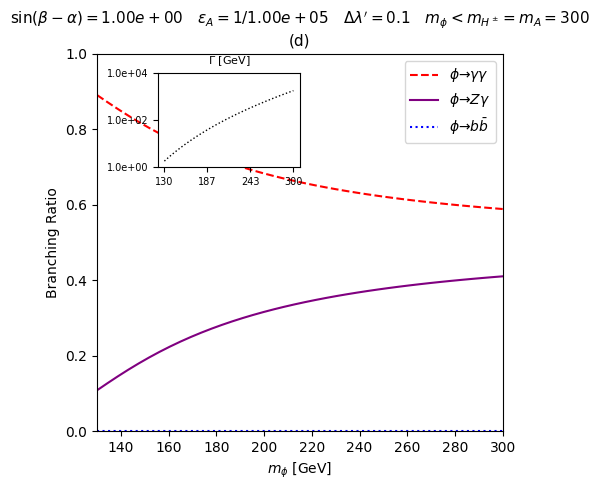

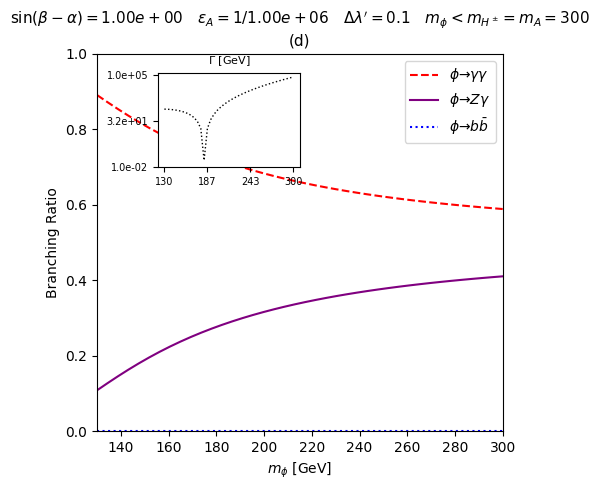

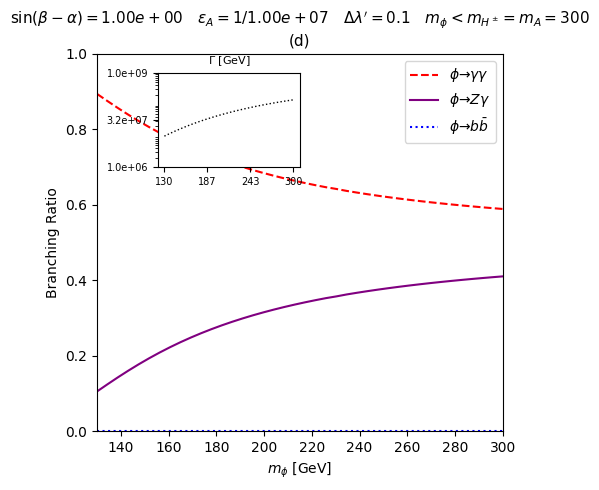

In [35]:
mphi_vals = np.linspace(130, 300, 40)
for tan_B in [1e5, 1e6, 1e7]:
    fixed_config = {
        'mA': 300,
        'm12': 0.033333,
        'lambda6': 0.1,
        'lambda7': 0.0,
        'sin_ba': 1,
        'tan_beta': tan_B
    }

    # set global lambda6 and lambda7 for the wrapper
    lambda6 = fixed_config['lambda6']
    lambda7 = fixed_config['lambda7']

    results = simulate_curve(mphi_vals, fixed_config['mA'], fixed_config['m12'], lambda6, lambda7, fixed_config['sin_ba'],
                         fixed_config['tan_beta'])
    plot_branchings(results, subplot_tag="(d)")
